# Preliminary

In [85]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

used_cars = pd.read_csv("datasets/cars.csv")

# Categorical pitfalls

## Memory savings
- Ex. Manufacturer name column in cars -> Huge memory savings ~90%
- Ex. Odometer value -> less significant
- Numeric variable save little to no memory, and object vars with many values save less than "proper" categorical variables
    - Ex. A Full Name variable would save little to no memory, because each value would be unique, whereas a sex variable would save a lot of memory 

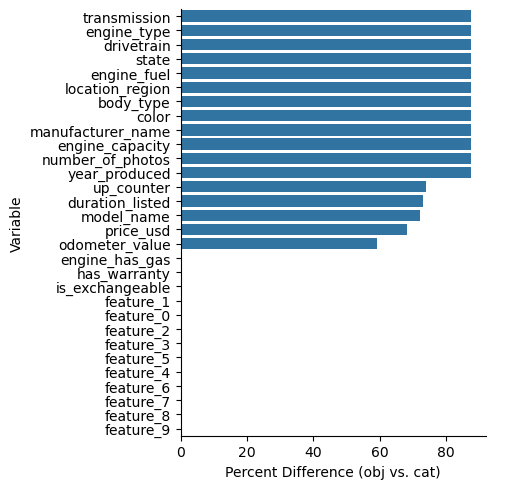

In [50]:
def memory_savings_calc(df,cols,verbose = False):
    saving_dict = {}
    for col in cols:
        nbytes_object = df[col].nbytes
        nbytes_cat = df[col].astype('category').nbytes
        percent_diff = 100*abs(nbytes_cat-nbytes_object)/nbytes_object
        if verbose:
            print("Column:",col)
            print("Bytes used as object:",nbytes_object)
            print("Bytes used as category:",nbytes_cat)
            print("Percent difference:",round(percent_diff,2),"% \n")
        saving_dict[col] = percent_diff
    return saving_dict

df = pd.Series(memory_savings_calc(used_cars, used_cars.columns.to_list())).sort_values(ascending=False)
g = sns.catplot(y=df.index, x=df,kind="bar")
g.set_axis_labels("Percent Difference (obj vs. cat)", "Variable")
plt.show()

## Using categories can be frustrating
- Using `.str` will always convert the Series to an object
- Using `.apply` will output a new Series as an object
- Methods of adding, removing, replacing, and setting categories handle missing categories differently
- A categorical Series is not a NumPy array -> Using NumPy functions will produce errors 

### Just for fun: Reusable functions to auto convert viable columns in a dataframe to categorical

In [ ]:
def col_to_category(col, thresh = 0.1):
    """ Converts string columns to categories *if* the number of unique values is less than thresh*len(col)"""
    if col.dtype == 'str' and col.nunique() < thresh*len(col):
        return col.astype('category')
    else:
        return col

def make_categorical(df, thresh = 0.1):
    """ Converts all string columns to categories if number of unique vals is less than thresh*len(col) """
    for col in df.columns:
        df[col] = col_to_category(df[col], thresh)
    return df

used_cars_new = make_categorical(used_cars)
used_cars_new.info()

<class 'pandas.DataFrame'>
RangeIndex: 38531 entries, 0 to 38530
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   manufacturer_name  38531 non-null  category
 1   model_name         38531 non-null  category
 2   transmission       38531 non-null  category
 3   color              38531 non-null  category
 4   odometer_value     38531 non-null  int64   
 5   year_produced      38531 non-null  int64   
 6   engine_fuel        38531 non-null  category
 7   engine_has_gas     38531 non-null  bool    
 8   engine_type        38531 non-null  category
 9   engine_capacity    38521 non-null  float64 
 10  body_type          38531 non-null  category
 11  has_warranty       38531 non-null  bool    
 12  state              38531 non-null  category
 13  drivetrain         38531 non-null  category
 14  price_usd          38531 non-null  float64 
 15  is_exchangeable    38531 non-null  bool    
 16  location_region

## Look for missing values
- Note: Inplace has been deprecated. have to explicitly reassign to column
- Use `df['col'].isnull()` to create a boolean mask for use with `df.loc[]`
- Use df

In [81]:
# set categories
used_cars["color"] = used_cars["color"].astype("category")
used_cars["color"] = used_cars["color"].cat.set_categories(["black","silver","blue"])
used_cars["color"].value_counts(dropna=False)

color
NaN       18172
black      7705
silver     6852
blue       5802
Name: count, dtype: int64

## Using NumPy arrays
- Common to convert categories using `df['cat'].astype(int)` for integer categories (ex. number of stars)
- Use `df['cat'].str...` to apply NumPy methods (ex. `df['cat'].str.contains("red")`)

# Label encoding

## What is label encoding? `.cat.codes`
- I'd call these values of a dummy variable
- Encodes categorical values as integers from 0 to n-1 where n is the number of categories
- -1 is used for missing values
- *NOT* the best method for use with machine learning models
- Ex. Label encoding of manufacturer name

`.cat.codes`
- If column is not ordinal, codes are assigned in alphabetical order

In [86]:
used_cars['manufacturer_code'] = (
    used_cars['manufacturer_name'].astype('category')
    ).cat.codes

used_cars[['manufacturer_name','manufacturer_code']].value_counts()

manufacturer_name  manufacturer_code
Volkswagen         48                   4243
Opel               35                   2759
BMW                3                    2610
Ford               14                   2566
Renault            39                   2493
Audi               2                    2468
Mercedes-Benz      31                   2237
Peugeot            36                   1909
Citroen            9                    1562
Nissan             34                   1361
Mazda              30                   1328
Toyota             47                   1246
Hyundai            18                   1116
Skoda              43                   1089
Kia                23                    912
Mitsubishi         33                    887
Fiat               13                    824
Honda              17                    797
Volvo              49                    721
ВАЗ                50                    481
Chevrolet          7                     436
Chrysler          

## Creating a code book
- Use `dict(zip(codes, categories))`

In [99]:
used_cars['manufacturer_code'] = (
    used_cars['manufacturer_name'].astype('category')
    ).cat.codes
name_map = dict(zip(used_cars['manufacturer_name'],used_cars['manufacturer_code']))
for key, value in name_map.items():
    print(key,':',value)

Subaru : 45
LADA : 24
Dodge : 12
УАЗ : 54
Kia : 23
Opel : 35
Москвич : 53
Alfa Romeo : 1
Acura : 0
Dacia : 10
Lexus : 27
Mitsubishi : 33
Lancia : 25
Citroen : 9
Mini : 32
Jaguar : 21
Porsche : 38
SsangYong : 44
Daewoo : 11
Geely : 15
ВАЗ : 50
Fiat : 13
Ford : 14
Renault : 39
Seat : 42
Rover : 40
Volkswagen : 48
Lifan : 28
Jeep : 22
Cadillac : 5
Audi : 2
ЗАЗ : 52
Toyota : 47
ГАЗ : 51
Volvo : 49
Chevrolet : 7
Great Wall : 16
Buick : 4
Pontiac : 37
Lincoln : 29
Hyundai : 18
Nissan : 34
Suzuki : 46
BMW : 3
Mazda : 30
Land Rover : 26
Iveco : 20
Skoda : 43
Saab : 41
Infiniti : 19
Chery : 6
Honda : 17
Mercedes-Benz : 31
Peugeot : 36
Chrysler : 8


## Using a code book
- Convert back to original categories using the `.map` method

In [107]:
# Convert manufacturer_name to a category
used_cars['manufacturer_name'] = used_cars['manufacturer_name'].astype('category')
# Create manufacturer_code column using .cat.codes
used_cars['manufacturer_code'] = used_cars['manufacturer_name'].cat.codes
# Create a code book using a zip inside a dict
name_map = dict(zip(used_cars['manufacturer_code'],used_cars['manufacturer_name']))
# Translate codes back into names using .map
print(used_cars['manufacturer_code'].map(name_map))

0          Subaru
1          Subaru
2          Subaru
3          Subaru
4          Subaru
           ...   
38526    Chrysler
38527    Chrysler
38528    Chrysler
38529    Chrysler
38530    Chrysler
Name: manufacturer_code, Length: 38531, dtype: str


## Boolean coding
- ex. "van_code" with a value of 1 if the body type contains "van" and 0 otherwise

In [116]:
import numpy as np
used_cars["van_code"] = np.where(used_cars["body_type"].str.contains("van",regex=False),1,0)
used_cars[['body_type','van_code']].value_counts()

body_type  van_code
sedan      0           13011
hatchback  0            7644
universal  0            5507
suv        0            5164
minivan    1            3608
minibus    0            1369
van        1             808
coupe      0             652
liftback   0             552
pickup     0             129
cabriolet  0              75
limousine  0              12
Name: count, dtype: int64

# One-hot encoding

## Why not label encoding?
- Using a ML process, categories encoded with lower values may be given less weights (ie. if 'diesel' is 0 and 'gas' is 3, gas may be given a greater weight)

## One-hot encoding with pandas
- `pd.get_dummies(data, columns, prefix)`
- I already know this, it creates a bunch of "is (category)?" variables. IE. one column with categories (A,B,C) becomes 2 columns: "Is A?", "Is B?", where 00 means "is C" 

In [119]:
used_cars['color'] = used_cars['color'].astype('category')
used_cars_onehot = pd.get_dummies(used_cars['color'])
used_cars_onehot

,black,blue,brown,green,grey,orange,other,red,silver,violet,white,yellow
0,False,False,False,False,False,False,False,False,True,False,False,False
1,False,True,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,True,False,False,False,False
3,False,True,False,False,False,False,False,False,False,False,False,False
4,True,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
38526,False,False,False,False,False,False,False,False,True,False,False,False
38527,False,True,False,False,False,False,False,False,False,False,False,False
38528,False,True,False,False,False,False,False,False,False,False,False,False
38529,True,False,False,False,False,False,False,False,False,False,False,False


## Specifying columns to use

In [120]:
used_cars_onehot = pd.get_dummies(used_cars, columns=["color"], prefix="")
used_cars_onehot.head()

,manufacturer_name,model_name,transmission,odometer_value,year_produced,engine_fuel,engine_has_gas,engine_type,engine_capacity,body_type,...,_brown,_green,_grey,_orange,_other,_red,_silver,_violet,_white,_yellow
0,Subaru,Outback,automatic,190000,2010,gasoline,False,gasoline,2.5,universal,...,False,False,False,False,False,False,True,False,False,False
1,Subaru,Outback,automatic,290000,2002,gasoline,False,gasoline,3.0,universal,...,False,False,False,False,False,False,False,False,False,False
2,Subaru,Forester,automatic,402000,2001,gasoline,False,gasoline,2.5,suv,...,False,False,False,False,False,True,False,False,False,False
3,Subaru,Impreza,mechanical,10000,1999,gasoline,False,gasoline,3.0,sedan,...,False,False,False,False,False,False,False,False,False,False
4,Subaru,Legacy,automatic,280000,2001,gasoline,False,gasoline,2.5,universal,...,False,False,False,False,False,False,False,False,False,False


## Notes:
- One-hot encoding may create too many features, risk overfitting
- NaN values don't get their own column